In [65]:
import pandas as pd

In [66]:
df = pd.read_csv('calories.csv')

In [67]:
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [68]:
df.isna().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [69]:
df = df.drop(['User_ID'], axis=1)

In [70]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [71]:
oe = OrdinalEncoder()
oe.fit(df[['Gender']]) #fit on gender

OrdinalEncoder()

In [72]:
df[['Gender']] = oe.transform(df[['Gender']]) #gender now equals the transformation of gender

In [73]:
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1.0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,0.0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,1.0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,0.0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,0.0,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...
14995,0.0,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,0.0,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,0.0,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,1.0,78,193.0,97.0,2.0,84.0,38.3,11.0


In [74]:
X = df.drop('Calories', axis=1)
y = df['Calories']

In [75]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=43)

In [77]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [78]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)  # No activation for regression
])
#dropout important to stop overfitting as mae and other measures were very high before, forces model to learn more and focus on different weights
model.compile(optimizer=keras.optimizers.Adam(), loss='mean_squared_error', metrics=['mae']) #changed the compilation to deal with continuious
#problem as before it was binary(eg surviving titanic 0,1)

/opt/miniconda3/envs/P1/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
y_train = y_train.to_numpy().reshape(-1, 1) #had to convert pandas series to numpy
y_test = y_test.to_numpy().reshape(-1, 1)

# Now you can fit the model
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6064.0146 - mae: 53.2738 - val_loss: 88.3210 - val_mae: 7.4393
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 263.9108 - mae: 11.9183 - val_loss: 37.2320 - val_mae: 4.6479
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 214.8599 - mae: 10.3839 - val_loss: 24.4488 - val_mae: 3.7470
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 189.5591 - mae: 9.6369 - val_loss: 21.6605 - val_mae: 3.3099
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 185.8646 - mae: 9.4446 - val_loss: 23.1345 - val_mae: 3.5013
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - loss: 178.3661 - mae: 9.2205 - val_loss: 10.7335 - val_mae: 2.3347
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 173.4748 - mae: 9.0296 - val_loss: 20.2420 - val_mae: 3.5158
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 165.9723 - mae: 8.8189 - val_loss: 20.0211 - val_mae: 3.4526
Epoch 9/25
375/375 ━━━

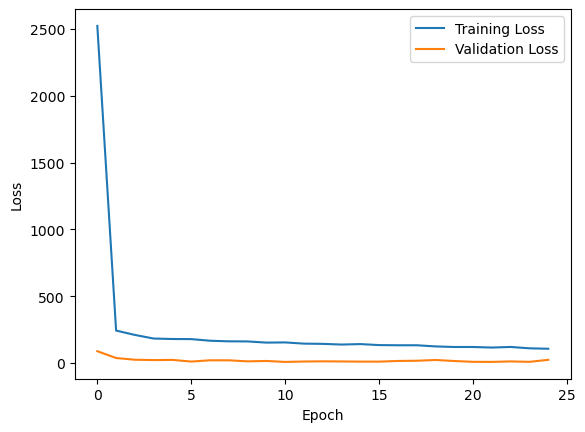

In [81]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [85]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"mae: {accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - loss: 23.2015 - mae: 3.9253
Test Loss: 23.7929
mae: 3.9122
